# Notebook 1 — Build & Train a CNN from Scratch (CIFAR-10)

**IOAI 2026 syllabus topics covered here:**
- *Convolutional Layers* (Theory + Practice)
- *Image Classification* (Practice)
- *Image Augmentation* (Practice) — flips & crops
- *Pooling (max/avg)* and *image data embeddings* (supporting topics)

**Goal:** by the end of this notebook you will have built a small Convolutional Neural Network (CNN) **from scratch** in PyTorch, trained it on real photos (CIFAR-10), measured how well it works, and *looked inside it* to see what it learned.

**How to use this notebook:** read every markdown cell *before* running the code below it. The markdown explains **why** we do each step; the code shows **how**.

> ⏱️ Designed to run top-to-bottom on a normal CPU in well under 10 minutes (we deliberately use a small data subset and few epochs — at a real olympiad you'd scale these up if given GPU time).

## 1. Why convolutions? (the theory you must actually understand)

An image is just a grid of numbers — for CIFAR-10, a `3 × 32 × 32` tensor (3 color channels: red, green, blue; 32×32 pixels). You *could* flatten it into a 3072-long vector and feed it to a plain fully-connected network, but that throws away two crucial facts about images:

1. **Locality** — a pixel is mostly related to its neighbours. An edge, a corner, a patch of fur: these are *local* patterns.
2. **Translation invariance** — a cat in the top-left corner is still a cat in the bottom-right. The *same* pattern detector should work everywhere in the image.

A **convolutional layer** bakes both ideas in:

- It slides a small **kernel** (e.g. 3×3 weights) across the image, computing a dot product between the kernel and each local patch. The output is a **feature map**: a grid telling you *how strongly that pattern appears at each location*.
- The **same** kernel weights are reused at every position (**weight sharing**) → translation invariance for free, and *far* fewer parameters than a fully-connected layer.
- One layer learns many kernels in parallel (the **output channels**). Early layers learn edges and colour blobs; deeper layers combine those into textures, parts, and objects.

**Shape arithmetic you should be able to do in your head** (it comes up constantly in olympiad debugging):

For input size $N$, kernel size $K$, padding $P$, stride $S$, the output spatial size is

$$\text{out} = \left\lfloor \frac{N + 2P - K}{S} \right\rfloor + 1$$

So a 3×3 conv with padding 1 and stride 1 keeps the size the same — that's why `kernel_size=3, padding=1` is everywhere.

**Pooling** (syllabus: max/avg pooling) shrinks feature maps. `MaxPool2d(2)` takes the maximum of each 2×2 block, halving height and width. Why max? We usually care *whether* a feature is present in a region, not its exact pixel position — max pooling keeps the strongest response and adds a little extra translation tolerance. Average pooling instead summarises the *overall* activity; it is typically used once at the very end of a network (global average pooling) to squash each feature map to a single number — turning the image into a fixed-size **embedding vector**.

## 2. Setup & reproducibility

Seeding every random number generator (Python, NumPy, PyTorch, and the dataloader workers) means anyone re-running this notebook gets the same results. At a competition, reproducibility is how you tell *"my change actually helped"* from *"I got a lucky random seed"*.

In [1]:
import random, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | device: {device}")
t_start = time.time()

PyTorch 2.12.0+cpu | device: cpu


## 3. Data loading + augmentation (flips & crops)

**Why augmentation?** Our subset has only a few thousand training images. A neural net with hundreds of thousands of parameters will happily *memorise* them (overfitting). **Data augmentation** fights this by showing the network slightly different versions of each image every epoch — effectively enlarging the dataset for free, and teaching the model invariances we *know* should hold:

- `RandomHorizontalFlip` — a mirrored cat is still a cat. (Note: you would **not** flip digits or text — augmentations must respect the label!)
- `RandomCrop(32, padding=4)` — pad the image by 4 pixels then crop a random 32×32 window. The object shifts a little each time → the network can't rely on exact pixel positions.

Augmentation is applied **only to training data**. The test set must stay fixed, otherwise your evaluation numbers would be noisy and not comparable.

We also `Normalize` with CIFAR-10's per-channel mean/std so inputs are roughly zero-mean, unit-variance — gradient descent converges much faster on well-scaled inputs.

In [2]:
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2470, 0.2435, 0.2616)

train_tf = T.Compose([
    T.RandomHorizontalFlip(p=0.5),      # augmentation: mirror images half the time
    T.RandomCrop(32, padding=4),        # augmentation: random shifts via pad+crop
    T.ToTensor(),                       # PIL image -> float tensor in [0,1], shape (3,32,32)
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])
test_tf = T.Compose([                   # NO augmentation on the test set
    T.ToTensor(),
    T.Normalize(CIFAR_MEAN, CIFAR_STD),
])

DATA_DIR = "./data"
USING_FAKE_DATA = False
try:
    train_full = torchvision.datasets.CIFAR10(DATA_DIR, train=True,  download=True, transform=train_tf)
    test_full  = torchvision.datasets.CIFAR10(DATA_DIR, train=False, download=True, transform=test_tf)
    classes = train_full.classes
except Exception as e:
    # ── FALLBACK (clearly marked) ────────────────────────────────────────────
    # If the CIFAR-10 download fails (no internet), we substitute torchvision's
    # FakeData (random noise images with random labels). The notebook still runs
    # end-to-end, but accuracy will hover near chance (10%) — that is expected.
    print(f"CIFAR-10 download failed ({e!r}) -> falling back to FakeData.")
    USING_FAKE_DATA = True
    train_full = torchvision.datasets.FakeData(5000, (3, 32, 32), 10, transform=train_tf)
    test_full  = torchvision.datasets.FakeData(1000, (3, 32, 32), 10, transform=test_tf)
    classes = [f"class_{i}" for i in range(10)]

# Small, *balanced-by-chance* subset so the whole notebook stays fast on CPU.
N_TRAIN, N_TEST = 4000, 1000
g = torch.Generator().manual_seed(SEED)
train_set = Subset(train_full, torch.randperm(len(train_full), generator=g)[:N_TRAIN].tolist())
test_set  = Subset(test_full,  torch.randperm(len(test_full),  generator=g)[:N_TEST].tolist())

train_loader = DataLoader(train_set, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_set,  batch_size=256, shuffle=False, num_workers=0)
print(f"train: {len(train_set)} images | test: {len(test_set)} images | classes: {classes}")

/work/.venvs/ioai/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


train: 4000 images | test: 1000 images | classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


### Look at the data (always do this first!)

Below: one row of raw test images, and the *same* training image pushed through the augmentation pipeline several times — notice the flips and small shifts. To display normalised tensors we have to *un-normalise* them first.

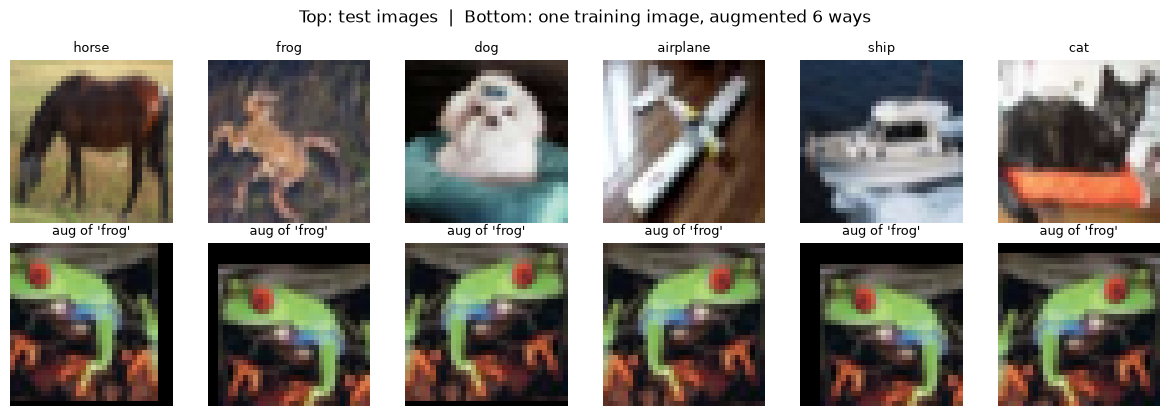

In [3]:
def unnormalize(img_t):
    mean = torch.tensor(CIFAR_MEAN).view(3,1,1)
    std  = torch.tensor(CIFAR_STD).view(3,1,1)
    return (img_t * std + mean).clamp(0, 1)

fig, axes = plt.subplots(2, 6, figsize=(12, 4.2))
for i in range(6):  # row 0: test images (no augmentation)
    img, lbl = test_set[i]
    axes[0, i].imshow(unnormalize(img).permute(1, 2, 0))
    axes[0, i].set_title(classes[lbl], fontsize=9); axes[0, i].axis("off")
for i in range(6):  # row 1: SAME train image, 6 random augmentations
    img, lbl = train_set[0]
    axes[1, i].imshow(unnormalize(img).permute(1, 2, 0))
    axes[1, i].set_title(f"aug of '{classes[lbl]}'", fontsize=9); axes[1, i].axis("off")
plt.suptitle("Top: test images  |  Bottom: one training image, augmented 6 ways")
plt.tight_layout(); plt.show()

## 4. Build the CNN

Our architecture is the classic recipe: **[Conv → BatchNorm → ReLU] ×2 → MaxPool**, repeated 3 times, then **global average pooling** and one linear layer.

Track the tensor shape as it flows through (this is the #1 skill for debugging models):

| stage | shape | what happened |
|---|---|---|
| input | `(B, 3, 32, 32)` | RGB image |
| block 1 | `(B, 32, 16, 16)` | 32 learned filters; pool halves H,W |
| block 2 | `(B, 64, 8, 8)`  | deeper = more channels, smaller maps |
| block 3 | `(B, 128, 4, 4)` | high-level part detectors |
| global avg pool | `(B, 128)` | **the image embedding** — one number per feature map |
| linear | `(B, 10)` | class scores (**logits**) |

Why each piece:
- **3×3 kernels, padding 1**: keeps spatial size; two stacked 3×3 convs see a 5×5 region but with fewer parameters and an extra nonlinearity than one 5×5 conv.
- **Channels grow (32→64→128) while spatial size shrinks**: we trade *where* information for *what* information.
- **ReLU** (`max(0,x)`): without a nonlinearity, stacked convs collapse into one big linear map — depth would be useless.
- **BatchNorm** standardises activations within each batch → much more stable, faster training, and lets us use a higher learning rate.
- **Global average pooling** instead of flattening: fewer parameters, and the 128-dim output is a proper **image embedding** (syllabus: data embeddings) — a compact vector summarising the image, reusable for retrieval or other heads.
- The network outputs raw **logits**; `CrossEntropyLoss` applies log-softmax internally, so we never add a softmax layer ourselves.

In [4]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes=10):
        super().__init__()
        def block(c_in, c_out):
            return nn.Sequential(
                nn.Conv2d(c_in, c_out, kernel_size=3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
                nn.Conv2d(c_out, c_out, kernel_size=3, padding=1), nn.BatchNorm2d(c_out), nn.ReLU(),
                nn.MaxPool2d(2),                       # halve H and W
            )
        self.features = nn.Sequential(block(3, 32), block(32, 64), block(64, 128))
        self.head = nn.Linear(128, n_classes)

    def forward(self, x):
        x = self.features(x)                # (B,128,4,4)
        x = F.adaptive_avg_pool2d(x, 1)     # global AVERAGE pooling -> (B,128,1,1)
        x = x.flatten(1)                    # (B,128)  <- the image embedding
        return self.head(x)                 # (B,10) logits

model = SmallCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\ntrainable parameters: {n_params:,}")

# sanity-check the shape arithmetic with a dummy batch
with torch.no_grad():
    print("dummy forward:", model(torch.zeros(2, 3, 32, 32, device=device)).shape)

SmallCNN(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU()
      (6): MaxPool2d(kernel_size=2, stride=

## 5. The training loop

Every PyTorch training loop has the same five-step heartbeat — memorise it:

1. `optimizer.zero_grad()` — clear old gradients (PyTorch *accumulates* them by default).
2. **forward**: `logits = model(x)`
3. **loss**: `loss = criterion(logits, y)` — cross-entropy compares logits to true labels.
4. **backward**: `loss.backward()` — autograd computes ∂loss/∂(every parameter).
5. **step**: `optimizer.step()` — nudge each parameter against its gradient.

Details that matter:
- **Adam** optimizer adapts a per-parameter learning rate — far less tuning needed than plain SGD, ideal under time pressure.
- `model.train()` vs `model.eval()`: BatchNorm behaves differently in each mode (batch statistics vs stored running statistics). Forgetting `eval()` at test time is a classic, silent bug.
- `torch.no_grad()` during evaluation: no gradients needed → less memory, faster.
- We log **test accuracy each epoch**. If train accuracy keeps climbing while test accuracy stalls or drops → **overfitting** (more augmentation / fewer parameters / earlier stopping would help).

In [5]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 3   # deliberately few, to stay CPU-friendly; accuracy keeps improving with more

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        correct += (model(x).argmax(dim=1) == y).sum().item()
        total += y.size(0)
    return correct / total

history = {"train_loss": [], "train_acc": [], "test_acc": []}
for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = correct = total = 0
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()              # 1. clear gradients
        logits = model(x)                  # 2. forward
        loss = criterion(logits, y)        # 3. loss
        loss.backward()                    # 4. backward (autograd)
        optimizer.step()                   # 5. update weights
        running_loss += loss.item() * y.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    tr_loss, tr_acc = running_loss / total, correct / total
    te_acc = evaluate(model, test_loader)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc); history["test_acc"].append(te_acc)
    print(f"epoch {epoch}/{EPOCHS} | train loss {tr_loss:.3f} | train acc {tr_acc:.3f} | test acc {te_acc:.3f}")

print(f"\nElapsed so far: {time.time() - t_start:.0f}s")

epoch 1/3 | train loss 1.876 | train acc 0.298 | test acc 0.275


epoch 2/3 | train loss 1.575 | train acc 0.418 | test acc 0.339


epoch 3/3 | train loss 1.433 | train acc 0.479 | test acc 0.500

Elapsed so far: 56s


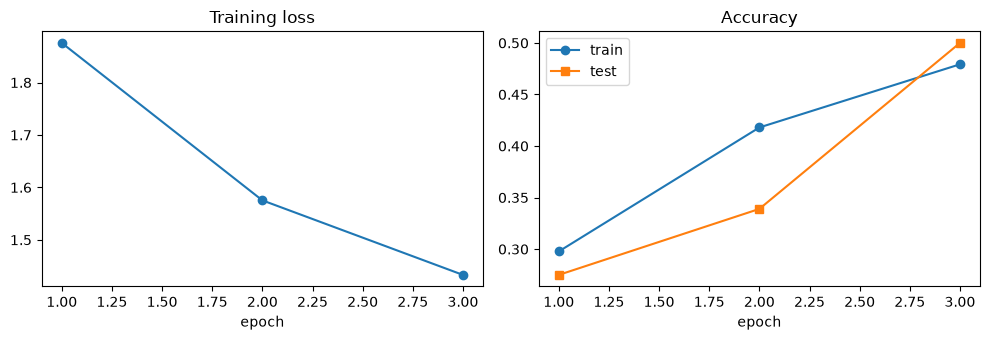

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].plot(range(1, EPOCHS+1), history["train_loss"], marker="o")
ax[0].set_title("Training loss"); ax[0].set_xlabel("epoch")
ax[1].plot(range(1, EPOCHS+1), history["train_acc"], marker="o", label="train")
ax[1].plot(range(1, EPOCHS+1), history["test_acc"], marker="s", label="test")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout(); plt.show()

## 6. Evaluation beyond a single number: the confusion matrix

Overall accuracy hides *which* mistakes the model makes. The **confusion matrix** counts, for every true class (rows), how often each class was predicted (columns). The diagonal is correct predictions; bright off-diagonal cells are systematic confusions.

On real CIFAR-10, expect the classic confusions: **cat ↔ dog**, **automobile ↔ truck**, **bird ↔ airplane** — visually similar categories. This tells you *where* to focus (better augmentation, more data for those classes, a bigger model).

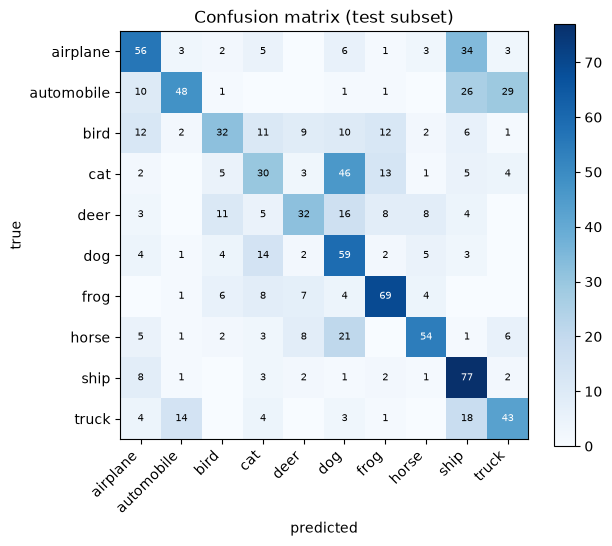

test accuracy: 0.500


In [7]:
from sklearn.metrics import confusion_matrix

model.eval()
all_preds, all_labels = [], []
all_imgs = []
with torch.no_grad():
    for x, y in test_loader:
        preds = model(x.to(device)).argmax(1).cpu()
        all_preds.append(preds); all_labels.append(y); all_imgs.append(x)
all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
all_imgs   = torch.cat(all_imgs)

cm = confusion_matrix(all_labels.numpy(), all_preds.numpy(), labels=list(range(10)))
fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(classes, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(classes)
ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title("Confusion matrix (test subset)")
for i in range(10):
    for j in range(10):
        if cm[i, j] > 0:
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=7)
plt.colorbar(im); plt.tight_layout(); plt.show()
print(f"test accuracy: {(all_preds == all_labels).float().mean():.3f}")

## 7. Look inside the network

### 7a. Learned first-layer filters
The first conv layer's kernels are `(32, 3, 3, 3)` — 32 little RGB patches we can render directly. After training on real images they typically look like **oriented edge detectors and colour-contrast blobs** — the network *rediscovers* classic image-processing filters on its own. (Deeper-layer filters mix many input channels, so they can't be shown as RGB images; people visualise those via the inputs that maximally activate them instead.)

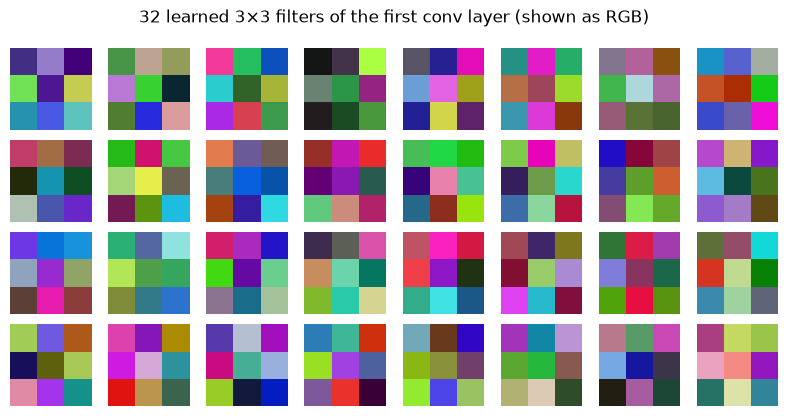

In [8]:
w = model.features[0][0].weight.detach().cpu()   # first Conv2d: (32, 3, 3, 3)
w_norm = (w - w.min()) / (w.max() - w.min())     # rescale to [0,1] for display
fig, axes = plt.subplots(4, 8, figsize=(8, 4.2))
for i, ax in enumerate(axes.flat):
    ax.imshow(w_norm[i].permute(1, 2, 0)); ax.axis("off")
plt.suptitle("32 learned 3×3 filters of the first conv layer (shown as RGB)")
plt.tight_layout(); plt.show()

### 7b. Misclassified images — your best debugging tool

Always *look at* what the model gets wrong. Errors usually fall into patterns: ambiguous photos, unusual poses, the systematic confusions from the matrix above. In a competition, ten minutes of staring at errors often suggests a better fix than an hour of blind hyperparameter tweaking.

500 / 1000 test images misclassified


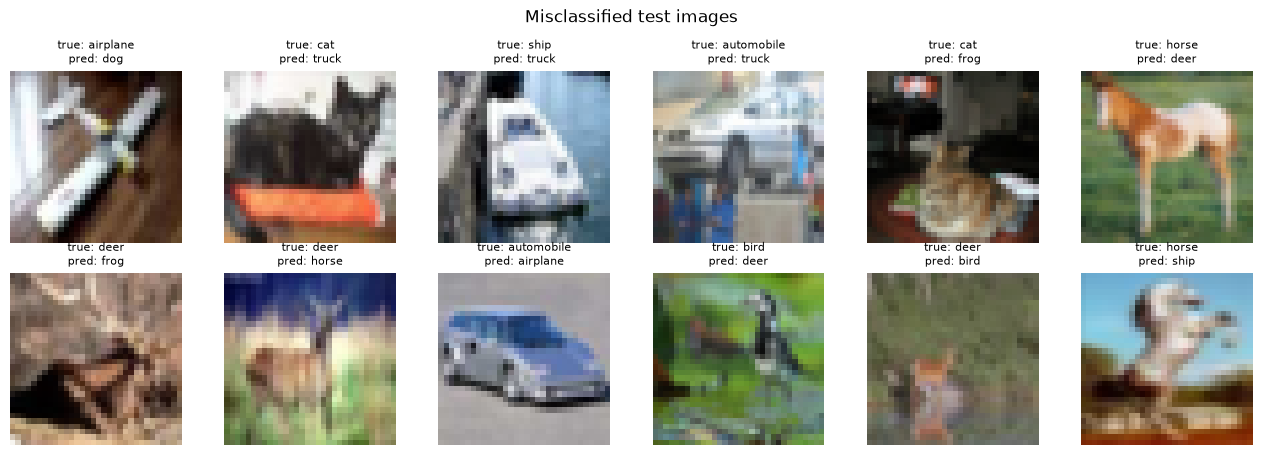

Total notebook runtime: 60s


In [9]:
wrong = (all_preds != all_labels).nonzero().flatten()
print(f"{len(wrong)} / {len(all_labels)} test images misclassified")
show = wrong[:12]
fig, axes = plt.subplots(2, 6, figsize=(13, 4.6))
for ax, idx in zip(axes.flat, show):
    ax.imshow(unnormalize(all_imgs[idx]).permute(1, 2, 0))
    ax.set_title(f"true: {classes[all_labels[idx]]}\npred: {classes[all_preds[idx]]}", fontsize=8)
    ax.axis("off")
plt.suptitle("Misclassified test images")
plt.tight_layout(); plt.show()
print(f"Total notebook runtime: {time.time() - t_start:.0f}s")

## 8. Recap & where this goes next

You now know, hands-on:
- **Convolution** = sliding shared-weight pattern detectors → feature maps; **pooling** shrinks maps and adds position tolerance; the output-size formula `⌊(N+2P−K)/S⌋+1`.
- **Augmentation** (flips, pad-and-crop) = free extra data + built-in invariances, train-set only.
- The universal **five-step training loop**, `train()`/`eval()` modes, and `no_grad()` evaluation.
- How to *evaluate honestly*: accuracy curves, **confusion matrix**, and inspecting **misclassified images** and **learned filters**.
- Global average pooling turns feature maps into a fixed-size **image embedding**.

With only ~4k images and 3 epochs this small CNN already beats random guessing (10%) by a wide margin, but it's far from the ~95% that modern methods reach. The biggest practical jump comes not from training longer, but from **starting from a network pretrained on millions of images** — that's *transfer learning*, the subject of **Notebook 2** (pretrained ResNet encoders, finetuning, and CLIP zero-shot classification).